# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**: all ETL steps from folder `/ELT_feature_extraction`
* **The purpose of this Notebook**: To extract the features from the raw data clean in the previous steps.
* **Enviroment**: Google Colab
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/)
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel)
* **Input**: `/preprocess_dataset`, containing the `*.npz` files created in ETL steps splitted in train, val and test.
* **Output:**
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`

# Imports

In [1]:
!pip install huggingface_hub

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import welch, hilbert, butter, filtfilt
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import HfApi
from huggingface_hub.utils import disable_progress_bars
from scipy.stats import entropy
from scipy.stats import zscore

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/process_dataset'

Mounted at /content/drive


# Definition of frequencies and bands

According to [AASM](https://aasm.org/)

| Wave | Frequency | Obs|
| --- | ---| --- |
| Delta | [0.5, 4] | N3 |
| Theta | [4, 8] | N1 |
| Alpha | [8, 13] | Wake, with eyes close |
| Sigma | [11, 16] | N2, Sleep spindle |
| Beta | [16, 30] | Wake |

In [4]:
# Set the sampling frequency, 100 Hz
SFREQ = 100

# We define the bands according to the AASM clinical table
EEG_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Sigma': (11, 16),    # Sleep spindles
    'Beta': (16, 30)
}

# Feature to extract

## Remove Artifacts

In [ ]:
def remove_artifacts_raw(x, sf=100):
    '''
    Remove artifacts from raw signals.

    Parameters:
        - x: shape (epochs, 3000)
        - sf: sampling frequency

    Return:
      - np.array of shape (epochs, 3000)
    '''

    cleaned = []

    for epoch in x:
        e = epoch.copy()

        # 1. Remove DC drift
        e = e - np.mean(e)

        # 2. High-pass 0.3 Hz
        b, a = butter(2, 0.3/(sf/2), btype='high')
        e = filtfilt(b, a, e)

        # 3. Clip extreme artifacts (EMG bursts, movement)
        thr = np.std(e) * 5
        e = np.clip(e, -thr, thr)

        cleaned.append(e)

    return np.array(cleaned)

## Detect Spindles

In [ ]:
def detect_spindles_raw(x, sf=100):
    '''
    Detect spindle events in raw signals.

    Parameters:
        - x: shape (epochs, 3000)
        - sf: sampling frequency

    Return:
        - list of spindle events per epoch
    '''
    # Bandpass 11–16 Hz
    b, a = butter(4, [11/(sf/2), 16/(sf/2)], btype='band')

    spindle_events = []

    for epoch in x:
        filtered = filtfilt(b, a, epoch)
        envelope = np.abs(hilbert(filtered))

        thr = np.mean(envelope) + 2*np.std(envelope)

        # detect segments above threshold
        above = envelope > thr

        events = []
        start = None

        for i, val in enumerate(above):
            if val and start is None:
                start = i
            if not val and start is not None:
                end = i
                duration = (end - start) / sf
                if 0.3 <= duration <= 2.0:
                    events.append((start, end))
                start = None

        spindle_events.append(events)

    return spindle_events

In [ ]:
def spindle_features_for_epoch(events, sf=100):
    '''Extract spindle features (count, mean duration).
    
    Parameters:
        - events: list of spindle events, each event is a tuple (start, end)
        - sf: sampling frequency

    Return:
        - list of spindle features
    '''
    count = len(events)
    if count == 0:
        return [0, 0]

    durations = [(e[1]-e[0])/sf for e in events]
    return [count, np.mean(durations)]

## Detect Slow Waves

In [ ]:
def detect_slow_waves_raw(x, sf=100):
    '''
    Detect slow waves (0.5–2 Hz)

    Parameters:
        - x: shape (epochs, 3000)
        - sf: sampling frequency

    Return:
        - list of slow waves per epoch
    '''
    # Bandpass 0.5–2 Hz
    b, a = butter(4, [0.5/(sf/2), 2/(sf/2)], btype='band')

    slow_events = []

    for epoch in x:
        filtered = filtfilt(b, a, epoch)

        # zero-crossings
        zero_cross = np.where(np.diff(np.sign(filtered)))[0]

        events = []
        for i in range(len(zero_cross)-2):
            start = zero_cross[i]
            mid = zero_cross[i+1]
            end = zero_cross[i+2]

            amp = np.max(filtered[start:end]) - np.min(filtered[start:end])
            duration = (end - start) / sf

            if 0.25 <= duration <= 1.5 and amp > 50:  # µV threshold
                events.append((start, end, amp))

        slow_events.append(events)

    return slow_events

In [ ]:
def slow_wave_features_for_epoch(events):
    '''Extract slow wave features (count, mean amplitude).
    
    Parameters:
        - events: list of slow wave events, each event is a tuple (start, end, amplitude)
    
    Return:
        - list of slow wave features
    '''
    if len(events) == 0:
        return [0, 0]

    amps = [e[2] for e in events]
    return [len(events), np.mean(amps)]

## Time features

In [8]:
def extract_time_features(epoch):
    '''
    Extract time features (mean, std, skewness, kurtosis).

    Parameters:
        - epoch: shape (3000,)

    Return:
        - list of time features
    '''
    mean_val = np.mean(epoch)
    std_val = np.std(epoch)
    skew_val = skew(epoch)
    kurt_val = kurtosis(epoch)

    zero_crosses = len(np.nonzero(np.diff(epoch > 0))[0])

    return [mean_val, std_val, skew_val, kurt_val, zero_crosses]

## Frequency features

In [ ]:
def extract_frequency_features(freqs, psd, EEG_BANDS):
    '''
    Extract frequency features (spectral entropy, abs band power)

    Parameters:
        - freqs: shape (n_freqs,)
        - psd: shape (n_freqs,)
        - EEG_BANDS: dict of band name to (fmin, fmax)
    
    Return:
        - list of frequency features
    '''
    # Spectral entropy
    psd_norm = psd / np.sum(psd)
    spec_entropy = entropy(psd_norm)

    # Absolute band powers
    band_powers = []
    for fmin, fmax in EEG_BANDS.values():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_powers.append(np.sum(psd[idx]))

    total_power = np.sum(psd)

    return spec_entropy, band_powers, total_power

## Spectal structure

In [ ]:
def extract_spectral_fine_structure(freqs, psd):
    '''Extract spectral fine structure features (HF power, flatness, centroid, spread, slope).
    
    Parameters:
        - freqs: shape (n_freqs,)
        - psd: shape (n_freqs,)
    Return:
        - list of spectral fine structure features
    '''
    hf_power = np.sum(psd[(freqs >= 30) & (freqs <= 45)])

    spectral_flatness = np.exp(np.mean(np.log(psd + 1e-8))) / (np.mean(psd) + 1e-8)
    spectral_centroid = np.sum(freqs * psd) / np.sum(psd)
    spectral_spread = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * psd) / np.sum(psd))
    slope = np.polyfit(freqs, psd, 1)[0]

    return [hf_power, spectral_flatness, spectral_centroid, spectral_spread, slope]

## Hjrth Parameters

In [ ]:
def extract_hjorth(epoch):
    '''Extract Hjorth parameters (mobility, complexity).
    
    Parameters:
        - epoch: shape (3000,)
    
    Return:
        - list of Hjorth parameters
    '''
    dx = np.diff(epoch)
    ddx = np.diff(dx)

    var_x = np.var(epoch)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)

    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0
    mobility_dx = np.sqrt(var_ddx / var_dx) if var_dx > 0 else 0
    complexity = mobility_dx / mobility if mobility > 0 else 0

    return [mobility, complexity]

## Relative Powers

In [ ]:
def extract_relative_powers(band_powers, total_power):
    '''Extract relative band powers.
    
    Parameters:
        - band_powers: list of band powers
        - total_power: total power
    
    Return:
        - list of relative band powers
    '''
    if total_power == 0:
        return [0] * len(band_powers)
    return [bp / total_power for bp in band_powers]

## Extraction

In [ ]:
def extract_features(epoch, SFREQ=SFREQ, EEG_BANDS=EEG_BANDS):
    '''
    Extract all features for a given epoch.
    
    Parameters:
        - epoch: shape (3000,)
        - SFREQ: sampling frequency
        - EEG_BANDS: dict of frequency bands
        
    Return:
        - list of all features
    '''
    features = []

    # Time domain
    features.extend(extract_time_features(epoch))

    # Hjorth
    features.extend(extract_hjorth(epoch))

    # PSD
    freqs, psd = welch(epoch, SFREQ, nperseg=SFREQ*2)

    # Frequency domain
    spec_entropy, band_powers, total_power = extract_frequency_features(freqs, psd, EEG_BANDS)
    features.append(spec_entropy)
    features.extend(band_powers)
    features.append(total_power)

    # Relative powers
    features.extend(extract_relative_powers(band_powers, total_power))

    # Spectral fine structure
    features.extend(extract_spectral_fine_structure(freqs, psd))

    return features

In [14]:
def process_folder(folder_path, output_csv):
    '''
    Process all files in a folder and save the extracted features to a CSV file.

    Parameters:
      - folder_path (str): Path to the folder containing the data files.
      - output_csv (str): Path to the CSV file where the extracted features will be saved.
    '''

    if os.path.exists(output_csv):
        print(f"File {output_csv} already exist.")
        return

    files = glob.glob(os.path.join(folder_path, "*.npz"))

    if not files:
        print(f"No data found {folder_path}")
        return

    print(f"Process {len(files)} files from {folder_path}...")

    all_features = []
    all_labels = []
    all_subject_ids = []
    all_dataset_sources = []

    for subject_id, f in enumerate(files, start=1):

        filename = os.path.basename(f).lower()

        if 'ucd' in filename:
            dataset_source = 1  # C3-A2
        elif 'hmc' in filename:
            dataset_source = 2  # C4-M1
        else:
            dataset_source = 0  # Fpz-Cz

        with np.load(f) as data:
            X = data['x']  # Shape: (number_epochs, 3000, 1)
            y = data['y']  # Shape: (number_epochs,)

        # Transform X into 2D: (nr_epochs, nr_samples)
        X = X.reshape(X.shape[0], -1)

        # ---------------------------------------------------------
        # 1) Artifact removal BEFORE any feature extraction
        # ---------------------------------------------------------
        X_clean = remove_artifacts_raw(X)

        # ---------------------------------------------------------
        # 2) Detect spindles and slow waves BEFORE epoch loop
        # ---------------------------------------------------------
        spindles = detect_spindles_raw(X_clean)
        slow_waves = detect_slow_waves_raw(X_clean)

        # ---------------------------------------------------------
        # 3) Extract features per epoch
        # ---------------------------------------------------------
        for i in range(X_clean.shape[0]):

            feats = extract_features(X_clean[i])

            # Add spindle features
            feats += spindle_features_for_epoch(spindles[i])

            # Add slow-wave features
            feats += slow_wave_features_for_epoch(slow_waves[i])

            all_features.append(feats)
            all_labels.append(y[i])
            all_subject_ids.append(subject_id)
            all_dataset_sources.append(dataset_source)

    # ---------------------------------------------------------
    # 4) Define column names (classic + new features)
    # ---------------------------------------------------------
    col_names = [
        'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
        'Mobility', 'Complexity', 'Spectral_Entropy',
        'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta',
        'Abs_Total',
        'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta',

        # NEW FEATURES:
        'Spindle_Count', 'Spindle_Duration',
        'SlowWave_Count', 'SlowWave_Amplitude',

        # EMG + spectral fine-structure (added inside extract_features)
        'HF_Power', 'Spectral_Flatness', 'Spectral_Centroid',
        'Spectral_Spread', 'Spectral_Slope'
    ]

    # ---------------------------------------------------------
    # 5) Build DataFrame
    # ---------------------------------------------------------
    df = pd.DataFrame(all_features, columns=col_names)

    df['Subject_ID'] = all_subject_ids
    df['Dataset_Source'] = all_dataset_sources
    df['Label'] = all_labels

    cols = ['Subject_ID', 'Dataset_Source'] + col_names + ['Label']
    df = df[cols]

    return df

# Z-Score Normalization

In [15]:
def normalize_by_subject(df, feature_cols):
    '''
    Apply Z-Score normalization per patient (Subject_ID).
    Brings signals from different electrodes (Fpz, C3, C4) to the same common denominator.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - feature_cols (list): List of column names

    Returns:
    - pd.DataFrame: The normalized DataFrame.
    '''
    df_norm = df.copy()
    for col in feature_cols:
        df_norm[col] = df_norm.groupby('Subject_ID')[col].transform(zscore)

    df_norm[feature_cols] = df_norm[feature_cols].fillna(0)
    return df_norm


# Temporal features

In [16]:
def extract_enhanced_temporal_features(df):
    '''
    Extract Ratios, Lags, Leads, Diffs and Rolling Stats using ultra-fast vectorized operations, respecting per-patient isolation.

    Parameters:
      - df (pd.DataFrame): The input DataFrame.

    Returns:
      - pd.DataFrame: The enhanced DataFrame.
    '''
    df_new = df.copy()
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']

    # 1. Creare Ratios (Rapoarte)
    eps = 1e-6
    df_new['Ratio_DeepSleep'] = df_new['Abs_Delta'] / (df_new['Abs_Beta'] + eps)
    df_new['Ratio_Transition'] = df_new['Abs_Theta'] / (df_new['Abs_Alpha'] + eps)

    feature_cols = [c for c in df_new.columns if c not in exclude_cols]
    grouped = df_new.groupby('Subject_ID')[feature_cols]

    # 2. Extragere Lags, Leads și Diferențe vectorizate
    lag1_df = grouped.shift(1).add_suffix('_lag1')
    lag2_df = grouped.shift(2).add_suffix('_lag2')
    lead1_df = grouped.shift(-1).add_suffix('_lead1')
    lead2_df = grouped.shift(-2).add_suffix('_lead2')
    diff_df = df_new[feature_cols].sub(grouped.shift(1)).add_suffix('_diff')

    # 3. Statistici Glisante (Rolling Stats)
    roll_mean_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean()).add_suffix('_roll_mean')
    roll_std_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).std()).add_suffix('_roll_std')

    # 4. Concatenare și curățare NaN-uri
    df_final = pd.concat([df_new, lag1_df, lag2_df, lead1_df, lead2_df, diff_df, roll_mean_df, roll_std_df], axis=1)
    df_final = df_final.groupby('Subject_ID', group_keys=False).apply(lambda g: g.bfill().ffill(), include_groups=False)

    return df_final

# Feature Extraction Pipeline

In [38]:
dfs = {}

for folder in ['train', 'val', 'test']:
    dfs[folder] = process_folder(
        base_path + '/' + folder,
        base_path + '/extracted_features/' + folder + '_features.csv',
    )

Process 259 files from /content/drive/MyDrive/sleep_data/process_dataset/train...
Process 56 files from /content/drive/MyDrive/sleep_data/process_dataset/val...
Process 57 files from /content/drive/MyDrive/sleep_data/process_dataset/test...


In [49]:
exclude = ['Subject_ID', 'Dataset_Source', 'Label']

for name, df in dfs.items():
    df_copy = df.copy()

    # 1. Salvează meta-coloanele separat
    meta = df[['Subject_ID', 'Dataset_Source', 'Label']].copy()

    # 2. Extrage enhanced temporal features (fără meta)
    df_copy = extract_enhanced_temporal_features(df_copy)

    # 3. Reatașează meta-coloanele
    df_copy[['Subject_ID', 'Dataset_Source', 'Label']] = meta

    # 4. Normalizează DOAR feature-urile
    feature_cols = [c for c in df_copy.columns if c not in exclude]
    df_copy[feature_cols] = normalize_by_subject(df_copy, feature_cols)[feature_cols]

    # 5. Salvează
    df_copy.to_csv(
        base_path + '/extracted_features/' + name + '_features.csv',
        index=False
    )

# Sanity Check

In [22]:
df = pd.read_csv(base_path+'/extracted_features/train_features.csv')

print("=== Technical check ===")
print(f"Table shape: {df.shape} (Rows: epochs, Columns: features)")

# Check if there are missing or infinite values
nan_count = df.isna().sum().sum()
inf_count = np.isinf(df.drop('Label', axis=1)).sum().sum()
print(f"Missing values ​​(NaN): {nan_count}")
print(f"Infinite values ​​(Inf): {inf_count}")

# If we have NaNs, we replace them with 0 so that the model doesn't break later.
if nan_count > 0 or inf_count > 0:
    print("Warning: Cleaning NaN/Inf values...")
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

=== Technical check ===
Table shape: (228213, 242) (Rows: epochs, Columns: features)
Missing values ​​(NaN): 0
Infinite values ​​(Inf): 0


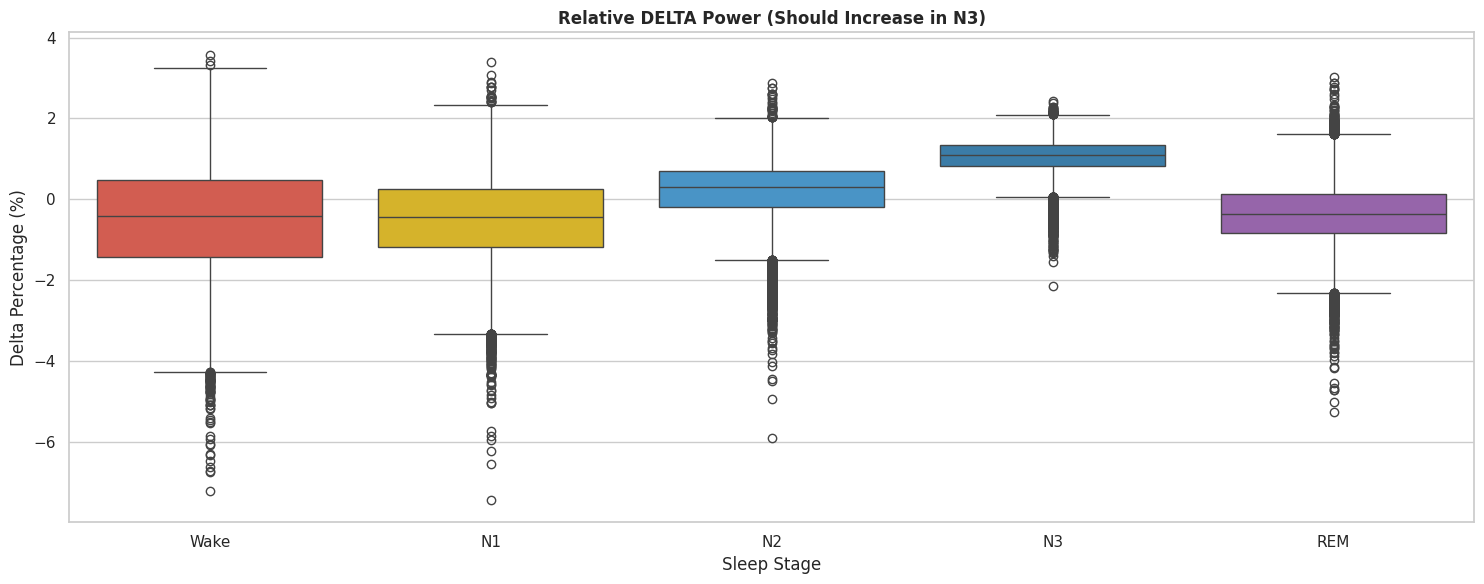

In [23]:
stage_mapping = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
df['Stage_Name'] = df['Label'].map(stage_mapping)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 1, figsize=(15, 6))
palette = ['#e74c3c', '#f1c40f', '#3498db', '#2980b9', '#9b59b6']

sns.boxplot(x='Stage_Name', y='Rel_Delta', data=df, ax=axes, palette=palette, hue='Stage_Name', legend=False, order=['Wake', 'N1', 'N2', 'N3', 'REM'])
axes.set_title('Relative DELTA Power (Should Increase in N3)', fontweight='bold')
axes.set_xlabel('Sleep Stage')
axes.set_ylabel('Delta Percentage (%)')

plt.tight_layout()
plt.show()

Graphical interpretation:
* The **line in the middle** of each box is the **median**.
* In stage **N3, approximately 85%** of brain activity is **Delta** waves
* Stages N1, N2 and REM: Have a much lower presence of Delta waves, which is normal.
* Wake (Red Box): Has a very high variation. **Eye movements, blinking and facial muscles introduce noise**, artifacts, into the EEG signal that, spectrally, frequently overlap with the Delta band.

In [50]:
display(df.describe())

,Subject_ID,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Mobility,Complexity,Spectral_Entropy,...,Spindle_Count,Spindle_Duration,SlowWave_Count,SlowWave_Amplitude,HF_Power,Spectral_Flatness,Spectral_Centroid,Spectral_Spread,Spectral_Slope,Label
count,48330.000000,48330.000000,48330.000000,4.833000e+04,48330.000000,48330.000000,48330.000000,48330.000000,48330.000000,48330.000000,...,4.833000e+04,48330.000000,48330.000000,48330.000000,4.833000e+04,48330.000000,48330.000000,48330.000000,4.833000e+04,48330.000000
mean,26.761453,0.729816,-28.456871,1.571805e+04,-0.036191,2.492601,797.295758,0.390069,3.159960,2.810158,...,6.762377e+07,0.054226,4.221343,5.293810,-9.362946e+06,2.006683,0.337180,19.585371,2.219940e+04,2.043927
std,16.232031,0.923796,477.058966,6.577105e+04,0.349532,2.503689,330.813652,0.172768,1.152364,0.523062,...,1.463515e+09,0.052900,2.510742,2.194841,6.272772e+07,1.669034,0.225525,35.383020,1.028141e+05,1.242743
min,1.000000,0.000000,-13945.495551,3.684638e-15,-2.740821,-1.856207,36.000000,0.077472,1.012790,0.665670,...,7.487443e-31,0.000010,0.706146,1.089448,-2.862380e+09,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,0.000000,-0.058437,9.368343e+00,-0.202807,0.821348,578.000000,0.266980,2.355580,2.433695,...,8.827557e-01,0.021070,2.515099,3.726215,-9.941433e-01,0.000000,0.000000,0.000000,0.000000e+00,1.000000
50%,26.000000,0.000000,-0.001484,1.377045e+01,-0.019740,1.760137,740.000000,0.358501,2.914753,2.826718,...,1.601232e+00,0.038802,3.648080,4.900791,-3.539364e-01,2.000000,0.380000,4.000000,6.024826e+01,2.000000
75%,39.000000,2.000000,0.055773,2.225392e+01,0.140591,3.348653,949.000000,0.472540,3.733371,3.175887,...,4.794700e+00,0.068706,5.124311,6.406488,-1.588449e-01,3.000000,0.475000,20.000000,7.702901e+01,3.000000
max,57.000000,2.000000,14211.199655,1.159170e+06,3.162101,109.585543,5951.000000,1.974744,13.997999,4.380932,...,1.760627e+11,1.000000,49.632922,15.126637,1.705335e+00,10.000000,1.560000,175.000000,2.155865e+06,4.000000


# Upload Hugging Face

In [52]:
repo_id = 'carmentheodora/Sleep_Quality_Dataset_Clean'
hf_token =  'SECRET'

In [ ]:
api = HfApi()

api.delete_folder(
    repo_id="carmentheodora/Sleep_Quality_Dataset_Clean",
    path_in_repo="extracted_features",
    repo_type="dataset",
    token=hf_token
)

CommitInfo(commit_url='https://huggingface.co/datasets/carmentheodora/Sleep_Quality_Dataset_Clean/commit/b03e423089d2ad3f2248fec22e322dfdc60c8537', commit_message='Delete folder extracted_features with huggingface_hub', commit_description='', oid='b03e423089d2ad3f2248fec22e322dfdc60c8537', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/carmentheodora/Sleep_Quality_Dataset_Clean', endpoint='https://huggingface.co', repo_type='dataset', repo_id='carmentheodora/Sleep_Quality_Dataset_Clean'), pr_revision=None, pr_num=None)

In [54]:
disable_progress_bars()

base_dir = base_path + '/extracted_features/'

api = HfApi()

print(f"Uploading '{base_dir}'...")

try:
    api.upload_folder(
        folder_path=base_dir,
        path_in_repo="extracted_features",
        repo_id=repo_id,
        repo_type="dataset",
        token=hf_token
    )
    print("Done upload in Hugging Face!")
except Exception as e:
    print(f"Error: {e}")

Uploading '/content/drive/MyDrive/sleep_data/process_dataset/extracted_features/'...
Done upload in Hugging Face!
